In [22]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import os
import skimage

# Leave Microscope Out

In [2]:
LOAD_PATH = '/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/'

In [4]:
df = pd.read_csv(f'{LOAD_PATH}figure5/figure5_LMO.csv')
df.head()

,Precision,Recall,F1,Model,Subset
0,0.63,0.61,0.62,mnDINO Hold Out,BBBC039
1,0.92,0.81,0.86,mnDINO Hold Out,mnDINO_data_01
2,0.75,0.94,0.84,mnDINO Hold Out,mnDINO_data_02
3,0.83,0.73,0.78,mnDINO Hold Out,MNFinder Data
4,0.74,0.62,0.67,mnDINO,BBBC039


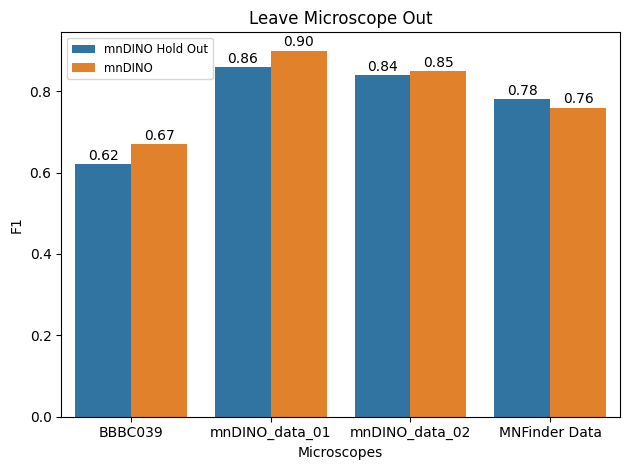

In [4]:
ax = sb.barplot(
    data=df,
    x='Subset',
    y='F1',
    hue='Model'
)
plt.xlabel('Microscopes')
plt.title('Leave Microscope Out')
plt.tight_layout()
plt.legend(loc='upper left', fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)
plt.show()

In [5]:
palette = dict(zip(df['Model'].unique(), sb.color_palette()))
palette

{'mnDINO Hold Out': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765),
 'mnDINO': (1.0, 0.4980392156862745, 0.054901960784313725)}

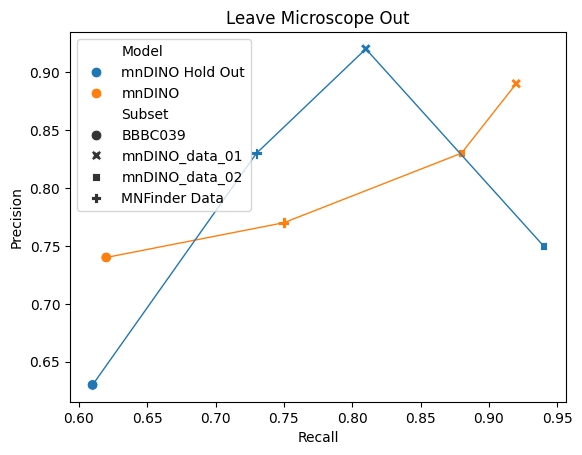

In [6]:
plot1 = sb.scatterplot(
    data=df,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Subset',
    s=60,
)
palette = dict(zip(df['Model'].unique(), sb.color_palette()))
for model, group_data in df.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-',
        linewidth=1
    )
    
plot1.set_title('Leave Microscope Out')
plt.show()

# Leave Cell-Line Out

In [ ]:
df2 = pd.read_csv(f'{LOAD_PATH}figure5/figure5_LCO.csv')
df2.head()

,Precision,Recall,F1,Model,Cell-line
0,0.55,0.62,0.59,mnDINO Hold Out,U2OS
1,0.72,0.87,0.79,mnDINO Hold Out,HeLa
2,0.85,0.79,0.82,mnDINO Hold Out,RPE1
3,0.74,0.62,0.67,mnDINO,U2OS
4,0.82,0.91,0.86,mnDINO,HeLa


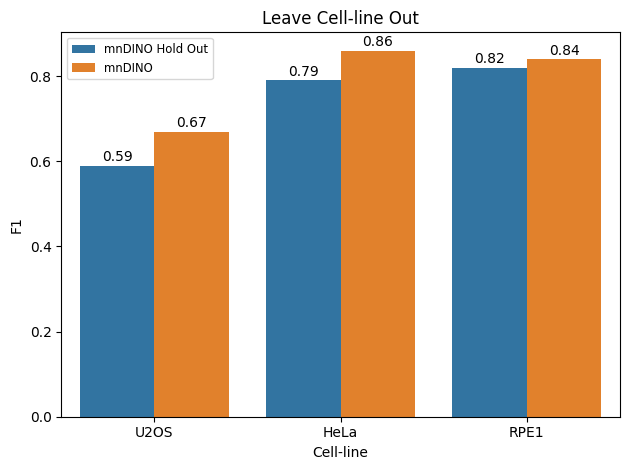

In [8]:
ax = sb.barplot(
    data=df2,
    x='Cell-line',
    y='F1',
    hue='Model'
)
plt.title('Leave Cell-line Out')
plt.tight_layout()
plt.legend(loc='upper left', fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)
plt.show()

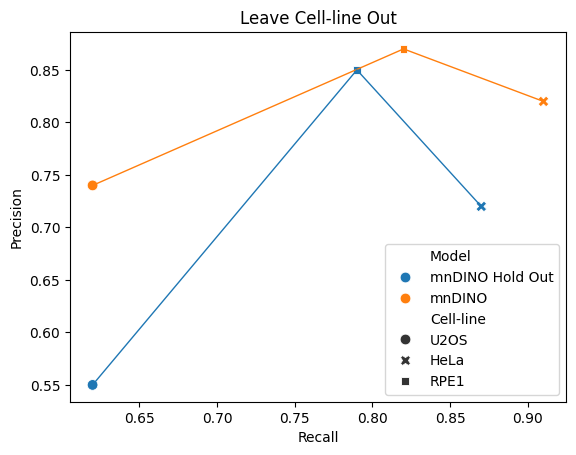

In [9]:
plot2 = sb.scatterplot(
    data=df2,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Cell-line',
    s=60
)

palette = dict(zip(df2['Model'].unique(), sb.color_palette()))
for model, group_data in df2.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-',
        linewidth=1
    )

plot2.set_title('Leave Cell-line Out')
plt.show()

# Computational Cost

In [3]:
cost = pd.read_csv(f'{LOAD_PATH}computational_cost/computational_cost.csv')
cost['Inference Time'] = cost['Inference Time'].apply(lambda x: int(x) if x > 1 else round(x, 1))
cost.head()

,Subset,Inference Time,F1,Step
0,BBBC039,8.0,0.665779,16
1,mnDINO_data_01,527.0,0.906966,16
2,mnDINO_data_02,441.0,0.881833,16
3,MNFinder Data,17.0,0.813847,16
4,BBBC039,2.0,0.666509,32


In [3]:
cost.Step.unique()

array([ 16,  32,  64, 128, 256])

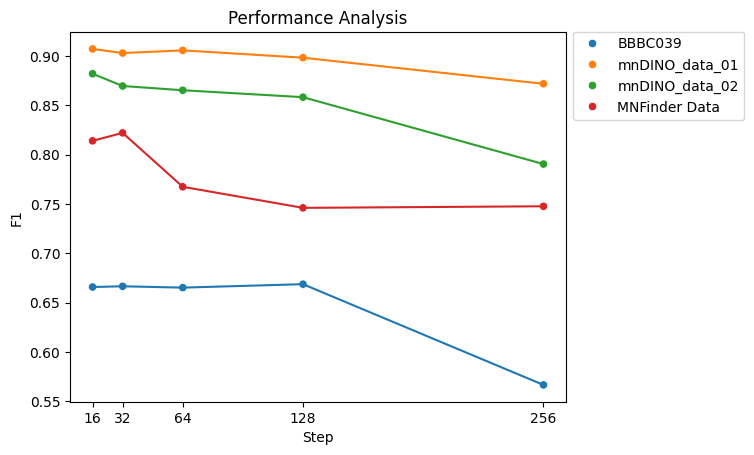

In [4]:
ax = sb.scatterplot(
    x=cost['Step'],
    y=cost['F1'],
    hue=cost['Subset'],
    sizes=(20, 150)
)

palette = dict(zip(cost['Subset'].unique(), sb.color_palette()))
for subset, group_data in cost.groupby('Subset'):
    group_data = group_data.sort_values('Step')
    plt.plot(
        group_data['Step'],
        group_data['F1'],
        color=palette[subset],
        linestyle='-'
    )

    
plt.xticks(cost.Step.unique())
plt.title('Performance Analysis')

handles, labels = ax.get_legend_handles_labels()


ax.legend(handles, labels, bbox_to_anchor=(1, 1.02), loc='upper left')
plt.show()

# Inference Time

In [66]:
df_time = pd.read_csv(f'{LOAD_PATH}computational_cost/inference_time.csv')
df = pd.read_csv('/scr/yren/annotated_mn_datasets/metadata.csv')
df_time.Subset.unique()

array(['BBBC039', 'mnDINO_data_01', 'mnDINO_data_02', 'MNFinder Data'],
      dtype=object)

- Total Inference Time across all methods

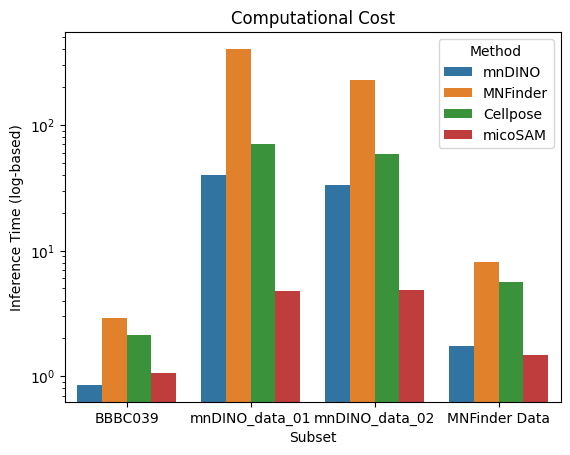

In [69]:
fig, ax1 = plt.subplots()

# Left y-axis with log scale
sb.barplot(
    data=df_time,
    x='Subset',
    y='Inference Time',
    hue='Method',
    ax=ax1
)
ax1.set_yscale('log')
ax1.set_ylabel('Inference Time (log-based)')
ax1.set_title('Computational Cost')


plt.show()

- Normalized Time for mnDINO

In [71]:
PATH = '/scr/yren/annotated_mn_datasets/train/images'
bbbc039_im = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'BBBC039')].reset_index().iloc[0].filenames))
mnDINO01_img = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'mnDINO_data_01')].reset_index().iloc[0].filenames))
mnDINO02_img = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'mnDINO_data_02')].reset_index().iloc[0].filenames))
mnfinder_img = skimage.io.imread(os.path.join(PATH, df[(df.split == 'train') & (df.datasets == 'mnfinder_train')].reset_index().iloc[0].filenames))

image_sources = {
    'BBBC039': bbbc039_im,
    'mnDINO_data_01': mnDINO01_img, 
    'mnDINO_data_02': mnDINO02_img,
    'MNFinder Data': mnfinder_img
}

for subset, img in image_sources.items():
    df_time.loc[(df_time['Subset'] == subset), ['H', 'W']] = img.shape[:2]

In [78]:
df_mndino

,Subset,Method,Inference Time,H,W,Scale
0,BBBC039,mnDINO,0.853484,520.0,696.0,88.359375
1,mnDINO_data_01,mnDINO,40.286448,2960.0,2960.0,2139.062500
2,mnDINO_data_02,mnDINO,32.974286,2720.0,2720.0,1806.250000
3,MNFinder Data,mnDINO,1.741493,768.0,869.0,162.937500


In [82]:
scale_value = df_mndino.loc[df_mndino.Subset == 'mnDINO_data_01', 'Scale'].item()
scale_value 

2139.0625

In [84]:
STEP_SIZE = 64
df_time['Scale'] = (df_time['H'] * df_time['W']) / (STEP_SIZE ** 2)
df_mndino = df_time[df_time.Method == 'mnDINO'].copy()
scale_value = df_mndino.loc[df_mndino.Subset == 'mnDINO_data_01', 'Scale'].item()
df_mndino['Scaled Inference Time'] = (
    df_mndino['Inference Time'] / (df_mndino['Scale'])
)

In [85]:
df_mndino

,Subset,Method,Inference Time,H,W,Scale,Scaled Inference Time
0,BBBC039,mnDINO,0.853484,520.0,696.0,88.359375,0.009659
1,mnDINO_data_01,mnDINO,40.286448,2960.0,2960.0,2139.062500,0.018834
2,mnDINO_data_02,mnDINO,32.974286,2720.0,2720.0,1806.250000,0.018256
3,MNFinder Data,mnDINO,1.741493,768.0,869.0,162.937500,0.010688


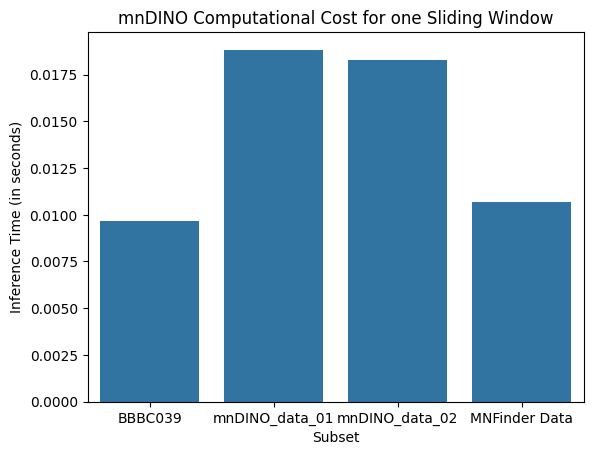

In [90]:
fig, ax1 = plt.subplots()

# Left y-axis with log scale
sb.barplot(
    data=df_mndino,
    x='Subset',
    y='Scaled Inference Time',
    ax=ax1
)
# ax1.set_yscale('log')
ax1.set_ylabel('Inference Time (in seconds)')
ax1.set_title('mnDINO Computational Cost for one Sliding Window')


plt.show()